## Descriptions

This notebook demonstrates how to run a PheWAS analysis on _All of Us_ with PheTK v0.2.1. Note that v0.2 has some syntax different from v0.1. The last stable version of v0.1 is v0.1.47.

This notebook was run with a dataproc VM with a main machine having 16CPUs and 104GB RAM and 2 workers having 4CPUs and 15GB RAM each.

## Concepts

__PheWAS__: Phenome-Wide Association Studies test the associations between a wide range of phenotypes in a study context, such as phenotype associations with a genetic variant, a condition, or a lab measurement, etc. The original PheWAS paper: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2859132/.

__Phecodes__: codes that are proxies for ICD codes in EHR, e.g., phecode for ICD-10-CM code R05 (cough) is RE_499.1 (phecodeX). Phecode version 1.2 has ~1,800 phecodes while phecodeX version 1.0 has ~3,600 phecodes (released Nov 2023). Phecode resources: https://phewascatalog.org/.

__PheTK__: a python package developed at Denny Lab at NHGRI for PheWAS analysis, with customized options for _All of Us_ users. 

GitHub: https://github.com/nhgritctran/PheTK. 

Reference: https://doi.org/10.1093/bioinformatics/btae719.

__Some key points about PheTK:__
- PheTK supports both phecode 1.2 and phecodeX 1.0.
- PheTK was developed to handle big data quickly and efficiently.
- Each PheTK module can be used independently depending on user's needs.

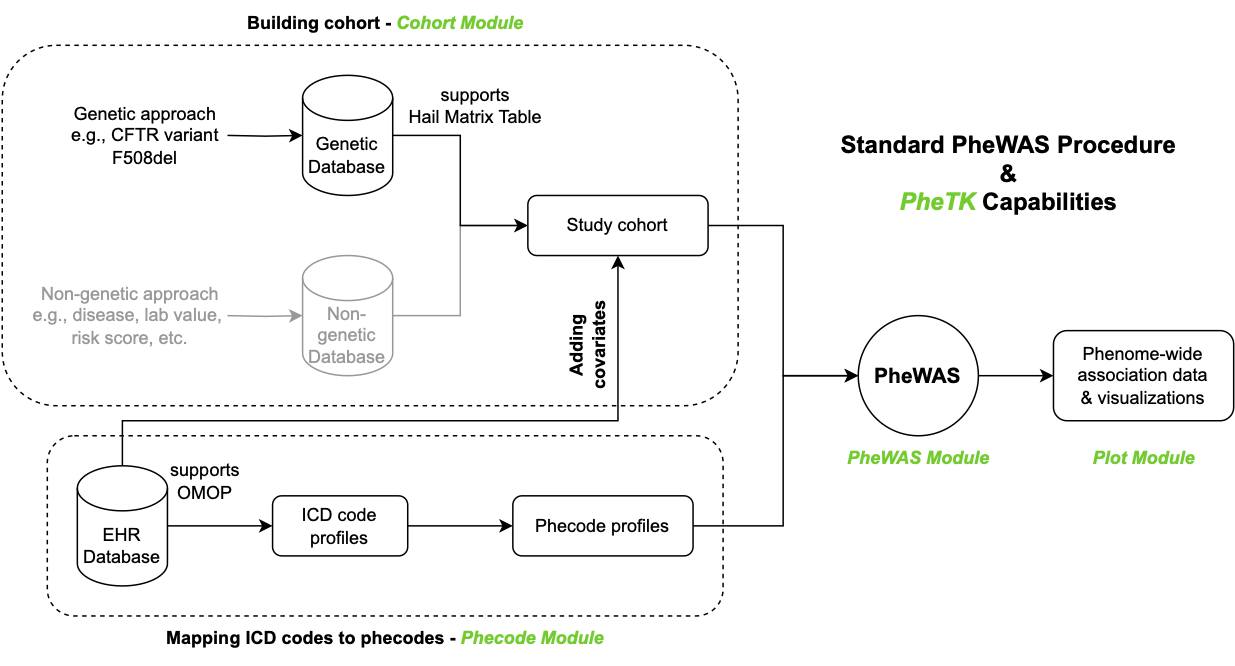

__Case study__: 
We are going to run PheWAS analysis for the most common APOE likely pathogenic/pathogenic variant on _All of Us_ (chr19:44908684:T:C) <sup>__1__</sup>. PheTK will be used to:
- Create a cohort by specifying genotype of interest
- Retrieve some covariates from cohort EHR data
- Retrieve ICD codes from EHR data, convert to phecodes and count these phecodes
- Run PheWAS with generated cohort and phecode profiles
- Visualize results with Manhattan plot

<sup>__1__</sup> The APOE variant information can be found in _All of Us_ public data browser (https://databrowser.researchallofus.org/variants/APOE), filtered by ClinVar significance and sorted by allele count:
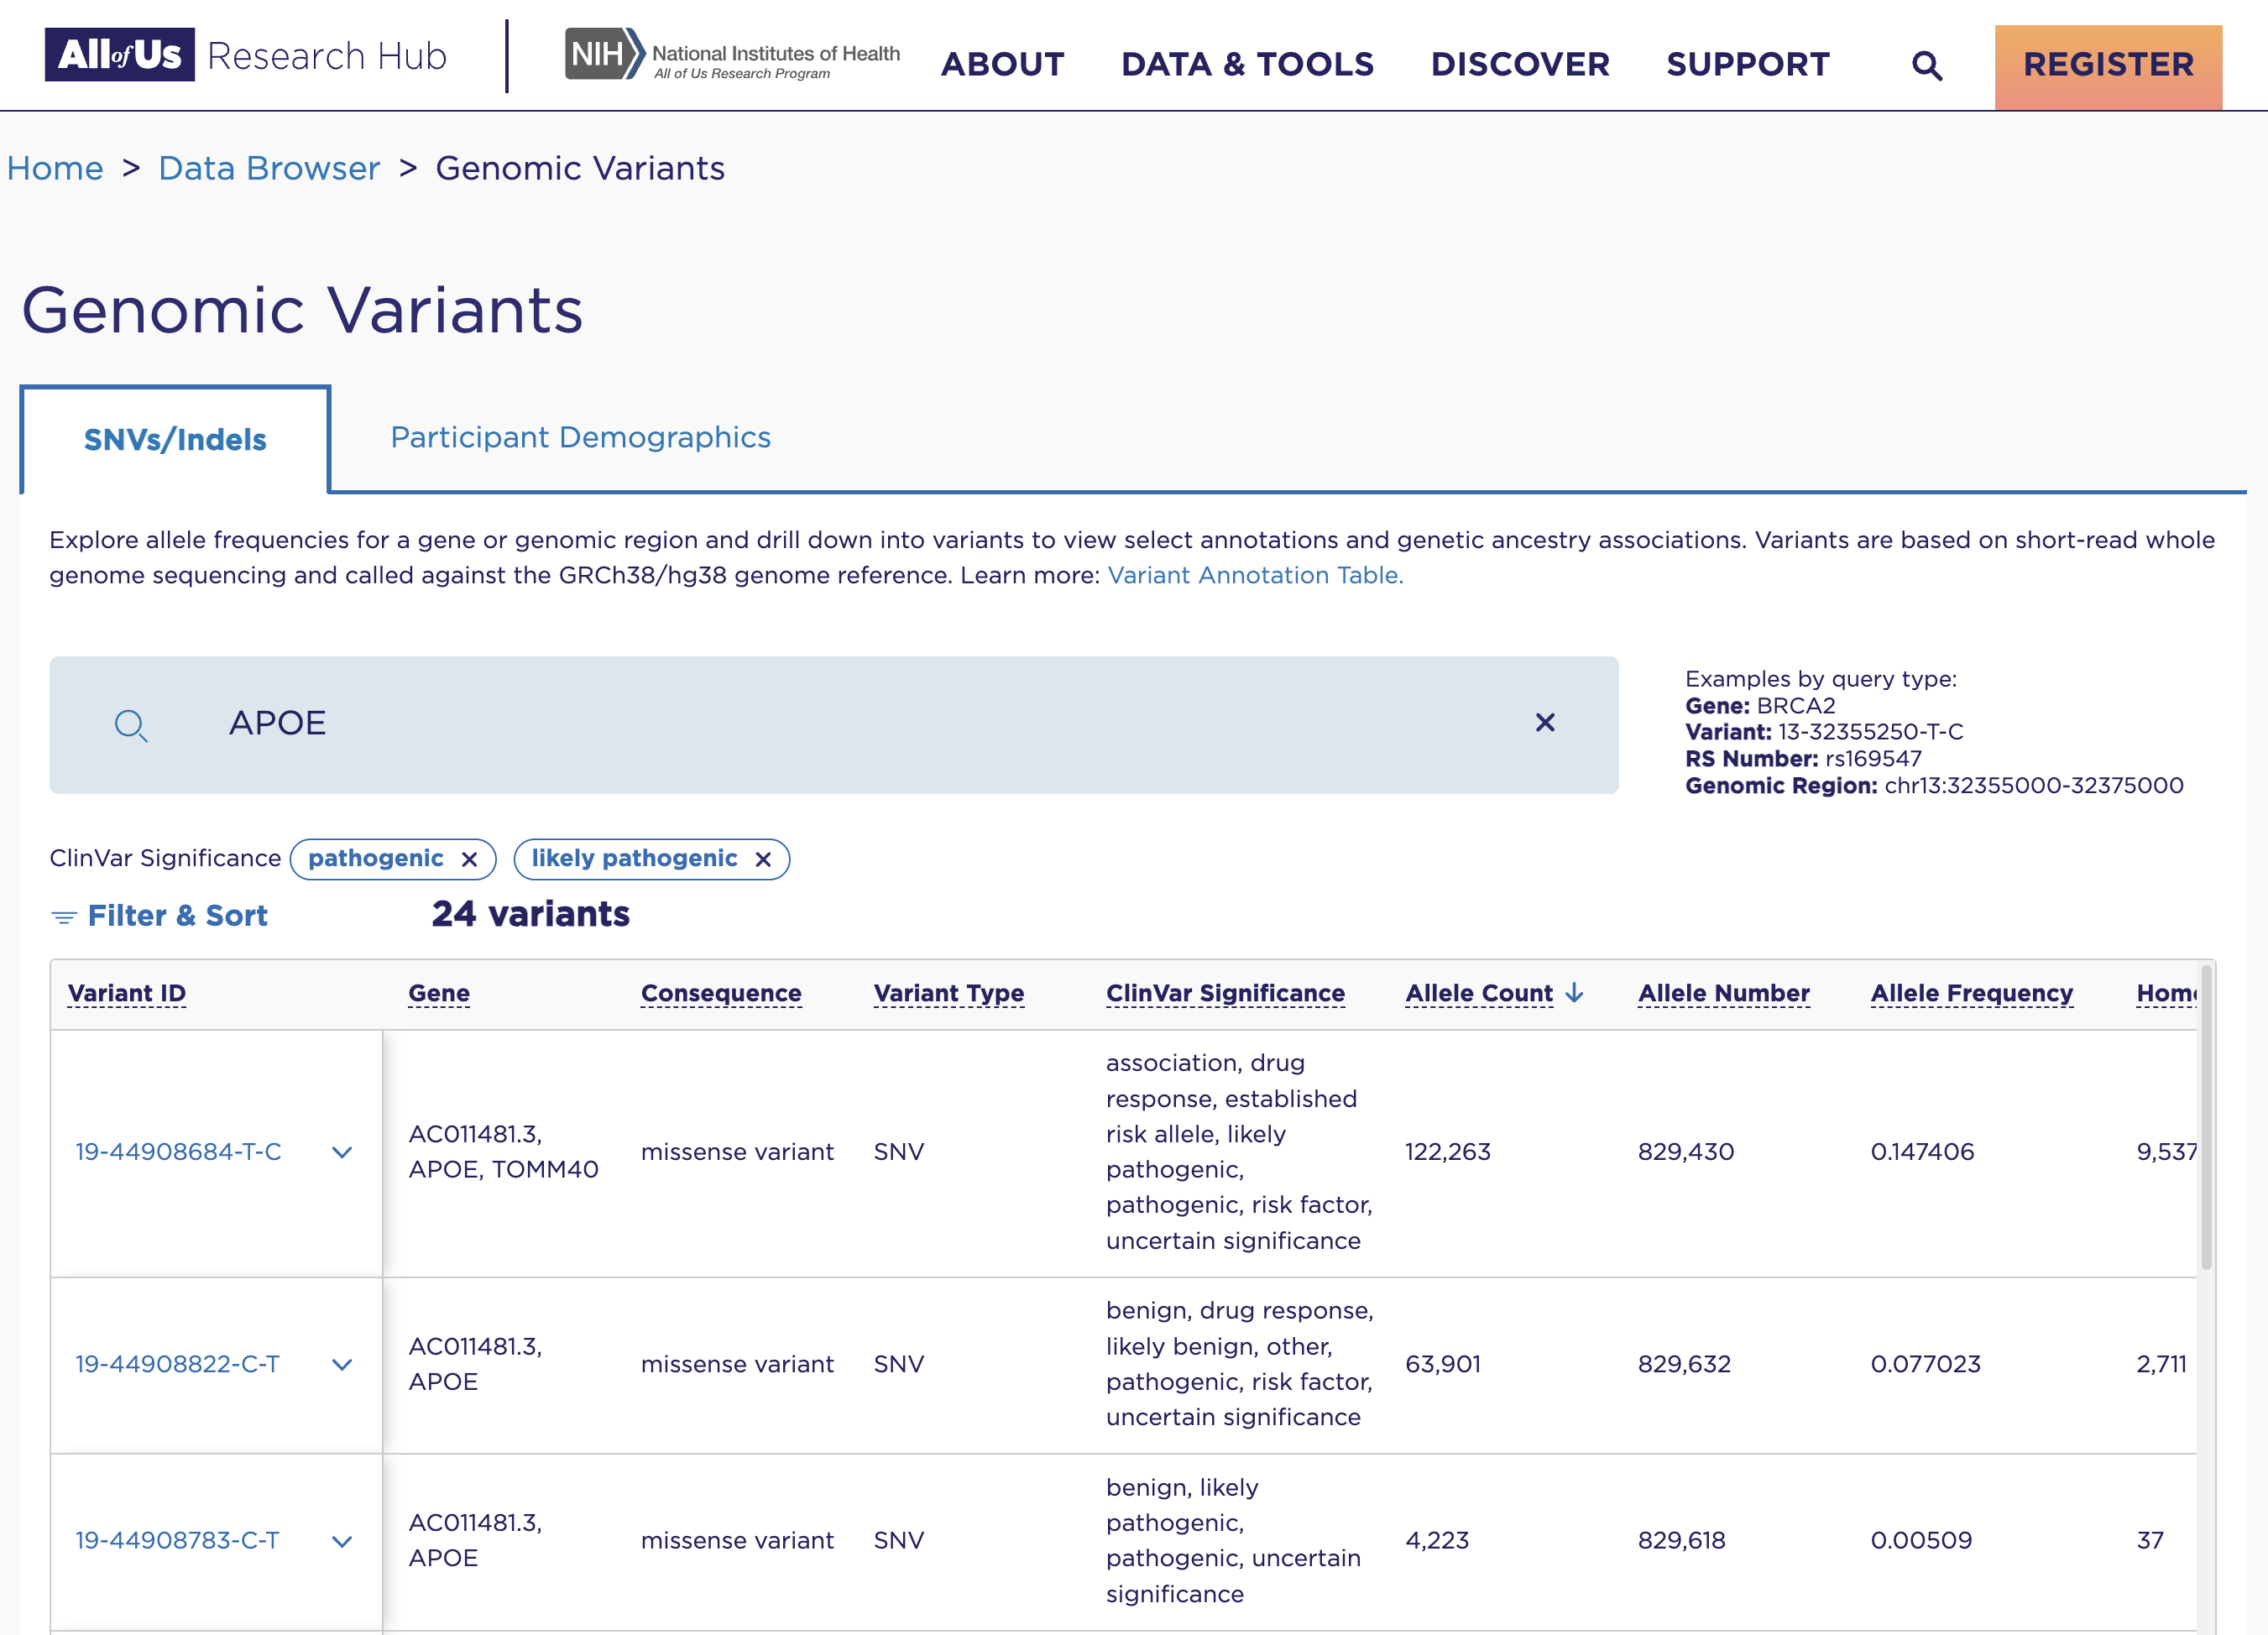

## PheTK installation

In [ ]:
!pip install --upgrade \
--index-url https://test.pypi.org/simple/ \
--extra-index-url https://pypi.org/simple/ \
phetk==0.2.1rc134

The above cell output was cleared to avoid exposing sensitive information.

In [2]:
!pip show PheTK | grep Version

Version: 0.2.1rc134


__Please restart the notebook kernel before proceeding to the next step.__

## Import

In [1]:
from phetk.cohort import Cohort
from phetk.phecode import Phecode
from phetk.phewas import PheWAS
from phetk.plot import Plot

## Logistic Regression PheWAS

For detailed usage of each module/function, please refer to PheTK GitHub repo at: https://github.com/nhgritctran/PheTK

### Create an _All of Us_ cohort by genoype

We will use method `by_genotype()` of class `Cohort` to create an APOE cohort by providing variant information and specifying which genotype(s) will be used as cases and controls.

This method interacts with Hail matrix table (for v7, PheTK defaults to ACAF table) that _All of Us_ uses to store variant data. It will take user's variant information and create an output csv file.

In [2]:
%%time
# instantiate class Cohort for _All of Us_ database
cohort = Cohort(platform="aou", aou_db_version=8)

# generate cohort by genotype
cohort.by_genotype(
    chromosome_number=19,
    genomic_position=44908684,
    ref_allele="T",
    alt_allele="C",
    gt_dict={0: "0/0", 1:["0/1", "1/1"]},
    output_file_path="rs429358_cohort.tsv"
)

Loading BokehJS ...

/opt/conda/lib/python3.10/site-packages/hail/context.py:350: UserWarning:

Using hl.init with a default_reference argument is deprecated. To set a default reference genome after initializing hail, call `hl.default_reference` with an argument to set the default reference genome.

/opt/conda/lib/python3.10/site-packages/hailtop/aiocloud/aiogoogle/user_config.py:43: UserWarning:

Reading spark-defaults.conf to determine GCS requester pays configuration. This is deprecated. Please use `hailctl config set gcs_requester_pays/project` and `hailctl config set gcs_requester_pays/buckets`.

Running on Apache Spark version 3.5.3
SparkUI available at http://all-of-us-5797-m.us-central1-c.c.terra-vpc-sc-7883f2cd.internal:41611
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.134-952ae203dbbe
LOGGING: writing to /home/jupyter/workspaces/phetkv8/hail-20250801-0318-0.2.134-952ae203dbbe.log



Locus chr19:44908684 found!


+----------------+------------+----------+---------+-----------+
| locus          | alleles    | filters  | a_index | was_split |
+----------------+------------+----------+---------+-----------+
| locus<GRCh38>  | array<str> | set<str> |   int32 |      bool |
+----------------+------------+----------+---------+-----------+
| chr19:44908684 | ["T","C"]  | {}       |       1 |     False |
+----------------+------------+----------+---------+-----------+

+--------------------------+---------------------------+
| variant_qc.gq_stats.mean | variant_qc.gq_stats.stdev |
+--------------------------+---------------------------+
|                  float64 |                   float64 |
+--------------------------+---------------------------+
|                 4.30e+01 |                  8.93e+00 |
+--------------------------+---------------------------+

+-------------------------+-------------------------+----------------------+
| variant_qc.gq_stats.min | variant_qc.gq_stats.max | variant_qc.call_rate |
+-------------------------+-------------------------+----------------------+
|                 float64 |                 float64 |              float64 |
+-------------------------+-------------------------+----------------------+
|                6.00e+00 |                9.90e+01 |             1.00e+00 |
+-------------------------+-------------------------+----------------------+

+---------------------+-------------------------+-----------------------+
| variant_qc.n_called | variant_qc.n_not_called | variant_qc.n_filtered |
+---------------------+-------------------------+-----------------------+
|               int64 |                   int64 |                 int64 |
+---------------------+-------------------------+-----------------------+
|              414715 |                       0 |                   115 |
+---------------------+-------------------------+-----------------------+

+------------------+----------------------+-------------------------+
| variant_qc.n_het | variant_qc.n_non_ref | variant_qc.het_freq_hwe |
+------------------+----------------------+-------------------------+
|            int64 |                int64 |                 float64 |
+------------------+----------------------+-------------------------+
|           103189 |               112726 |                2.51e-01 |
+------------------+----------------------+-------------------------+

+------------------------+-------------------------------+--------------+
| variant_qc.p_value_hwe | variant_qc.p_value_excess_het | info.AC      |
+------------------------+-------------------------------+--------------+
|                float64 |                       float64 | array<int32> |
+------------------------+-------------------------------+--------------+
|               1.05e-10 |                      1.00e+00 | [122263]     |
+------------------------+-------------------------------+--------------+

+----------------+---------+-----------------------+
| info.AF        | info.AN | info.homozygote_count |
+----------------+---------+-----------------------+
| array<float64> |   int32 | array<int32>          |
+----------------+---------+-----------------------+
| [1.47e-01]     |  829430 | [301989,9537]         |
+----------------+---------+-----------------------+

2025-08-01 03:19:35.842 Hail: WARN: entries(): Resulting entries table is sorted by '(row_key, col_key)'.
    To preserve row-major matrix table order, first unkey columns with 'key_cols_by()'



Variant chr19:44908684:T:C found!


+----------------+------------+----------+---------+-----------+
| locus          | alleles    | filters  | a_index | was_split |
+----------------+------------+----------+---------+-----------+
| locus<GRCh38>  | array<str> | set<str> |   int32 |      bool |
+----------------+------------+----------+---------+-----------+
| chr19:44908684 | ["T","C"]  | {}       |       1 |     False |
+----------------+------------+----------+---------+-----------+

+--------------------------+---------------------------+
| variant_qc.gq_stats.mean | variant_qc.gq_stats.stdev |
+--------------------------+---------------------------+
|                  float64 |                   float64 |
+--------------------------+---------------------------+
|                 4.30e+01 |                  8.93e+00 |
+--------------------------+---------------------------+

+-------------------------+-------------------------+----------------------+
| variant_qc.gq_stats.min | variant_qc.gq_stats.max | variant_qc.call_rate |
+-------------------------+-------------------------+----------------------+
|                 float64 |                 float64 |              float64 |
+-------------------------+-------------------------+----------------------+
|                6.00e+00 |                9.90e+01 |             1.00e+00 |
+-------------------------+-------------------------+----------------------+

+---------------------+-------------------------+-----------------------+
| variant_qc.n_called | variant_qc.n_not_called | variant_qc.n_filtered |
+---------------------+-------------------------+-----------------------+
|               int64 |                   int64 |                 int64 |
+---------------------+-------------------------+-----------------------+
|              414715 |                       0 |                   115 |
+---------------------+-------------------------+-----------------------+

+------------------+----------------------+-------------------------+
| variant_qc.n_het | variant_qc.n_non_ref | variant_qc.het_freq_hwe |
+------------------+----------------------+-------------------------+
|            int64 |                int64 |                 float64 |
+------------------+----------------------+-------------------------+
|           103189 |               112726 |                2.51e-01 |
+------------------+----------------------+-------------------------+

+------------------------+-------------------------------+--------------+
| variant_qc.p_value_hwe | variant_qc.p_value_excess_het | info.AC      |
+------------------------+-------------------------------+--------------+
|                float64 |                       float64 | array<int32> |
+------------------------+-------------------------------+--------------+
|               1.05e-10 |                      1.00e+00 | [122263]     |
+------------------------+-------------------------------+--------------+

+----------------+---------+-----------------------+
| info.AF        | info.AN | info.homozygote_count |
+----------------+---------+-----------------------+
| array<float64> |   int32 | array<int32>          |
+----------------+---------+-----------------------+
| [1.47e-01]     |  829430 | [301989,9537]         |
+----------------+---------+-----------------------+


Cohort size: 414703 participants
Genotype 0: 301989 participants
Genotype 1: 112714 participants

Cohort data saved as rs429358_cohort.tsv

CPU times: user 4.94 s, sys: 868 ms, total: 5.81 s
Wall time: 2min


### Add covariates to created cohort

After creating cohort, we will use method `add_covariates()` of class `Cohort` to generate some covariates from _All of Us_ EHR data.

This method utilizes SQL scripts and some data processing steps to generate covariates from _All of Us_ EHR data stored as Google BigQuery datasets. It takes a cohort csv file as input and generates a new csv file as output with added covariate data.

__Note__: PheTK offers extraction for some common covariates, which may or may not be suitable for your own studies. Each study requires a unique set of covariates tailored to its specific research objectives and data characteristics.

In [3]:
%%time
cohort.add_covariates(
    cohort_file_path="rs429358_cohort.tsv",
    age_at_last_ehr_event=True,
    sex_at_birth=True,
    first_n_pcs=5,
    drop_nulls=True,
    output_file_path="rs429358_cohort_with_covariates.tsv"
)

100%|██████████| 42/42 [02:20<00:00,  3.35s/it]



Cohort size: 280444 participants
Genotype 0: 204525 participants
Genotype 1: 75919 participants

Cohort data saved as rs429358_cohort_with_covariates.tsv

CPU times: user 16min 9s, sys: 28.6 s, total: 16min 38s
Wall time: 2min 21s


### Generate phecode profiles for _All of Us_ participants

Before being able to run PheWAS for the created cohort, we need to generate phecode profiles for cohort participants, using method `count_phecode()` of class `Phecode`.

This methods extracts all ICD codes of every participants in _All of Us_, maps extracted ICD codes to phecodes, and then counts number of occurrences of each phecode on distinct dates. It takes some user's input and generates a csv file as output.

In [4]:
%%time
# instantiate class Phecode and provide some basic information
phecode = Phecode(platform="aou")

# generate phecode profiles/counts
phecode.count_phecode(
    phecode_version="X", 
    output_file_path="aou_phecode_counts.tsv"
)

Start querying ICD codes...
Done!

Mapping ICD codes to phecodeX...
Successfully generated phecodeX counts for cohort participants!

Saved to aou_phecode_counts.tsv

CPU times: user 4min 1s, sys: 1min 29s, total: 5min 31s
Wall time: 4min 41s


### Run PheWAS

Having both cohort data and phecode profiles, we are now ready to run PheWAS!

In this example:
- We are running PheWAS using phecode 1.2. 
- PheWAS will be adjusted for "age_at_last_event", "sex_at_birth", "pc1", "pc2", "pc3", "pc4", and "pc5". 
- Our variable of interest, for which summary statistics will be generated, is "case". 
- To be considered as a case for a phecode, a participant must have a minimum count of 2 for that phecode (min_phecode_count=2). 
- There must be at least 50 cases and 50 controls for a phecode to be tested (min_cases=50)

Please note that, the column names used as parameter inputs here are specific for this example data. Users need to change these inputs based on their data.

In [5]:
%%time
# instantiate class PheWAS and provide information for the PheWAS run
phewas = PheWAS(
    phecode_version="X",
    phecode_count_file_path="aou_phecode_counts.tsv",
    cohort_file_path="rs429358_cohort_with_covariates.tsv",
    sex_at_birth_col="sex_at_birth",
    male_as_one=True,
    covariate_cols=[
        "age_at_last_ehr_event", "sex_at_birth",
        "pc1", "pc2", "pc3", "pc4", "pc5"
    ],
    independent_variable_of_interest="genotype",
    min_cases=50,
    min_phecode_count=2,
    method="logit",
    output_file_path="rs429358_phewas_results.tsv"
)

# run PheWAS
phewas.run()

~~~~~~~~~~~~~~~~~~~~~~~~~    Creating PheWAS Object    ~~~~~~~~~~~~~~~~~~~~~~~~~

Cohort size:  280444
genotype descriptions:  shape: (2, 2)
┌──────────┬────────┐
│ genotype ┆ count  │
│ ---      ┆ ---    │
│ i64      ┆ u32    │
╞══════════╪════════╡
│ 1        ┆ 75919  │
│ 0        ┆ 204525 │
└──────────┴────────┘

Number of unique phecodes in cohort:  3430
Total number of phecode events:  20812932
Number of phecode batches to process:  3430

Analysis method:  Logistic regression

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~    Running PheWAS    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Parallelization method: multithreading
Number of workers: 11

Creating ThreadPoolExecutor...
Submitting jobs to workers...
Submitted 3430 jobs. Running regressions...


Processed: 100%|██████████| 3430/3430 [38:11<00:00,  1.50it/s] 


Multithreading completed successfully.
Combining 2517 result files...


Reading files: 100%|██████████| 2517/2517 [00:03<00:00, 802.44it/s]


Concatenating results...
Cleaning up temporary files...


Cleaning files: 100%|██████████| 2517/2517 [00:00<00:00, 36422.00it/s]



~~~~~~~~~~~~~~~~~~~~~~~~~~~~    PheWAS Completed    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Number of participants in cohort: 280444
Number of phecodes in cohort: 3430
Number of phecodes having less than 50 cases or controls: 913
Number of phecodes tested: 2517
Suggested Bonferroni correction (-log₁₀ scale): 4.701913211212344
Number of phecodes above Bonferroni correction: 16

PheWAS results saved to rs429358_phewas_results.tsv 

CPU times: user 5h 47min 14s, sys: 4h 8min 32s, total: 9h 55min 46s
Wall time: 38min 16s


### Result visualization

In [6]:
# instantiate class Plot with PheWAS results as input
p = Plot("rs429358_phewas_results.tsv")

#### Manhattan plot

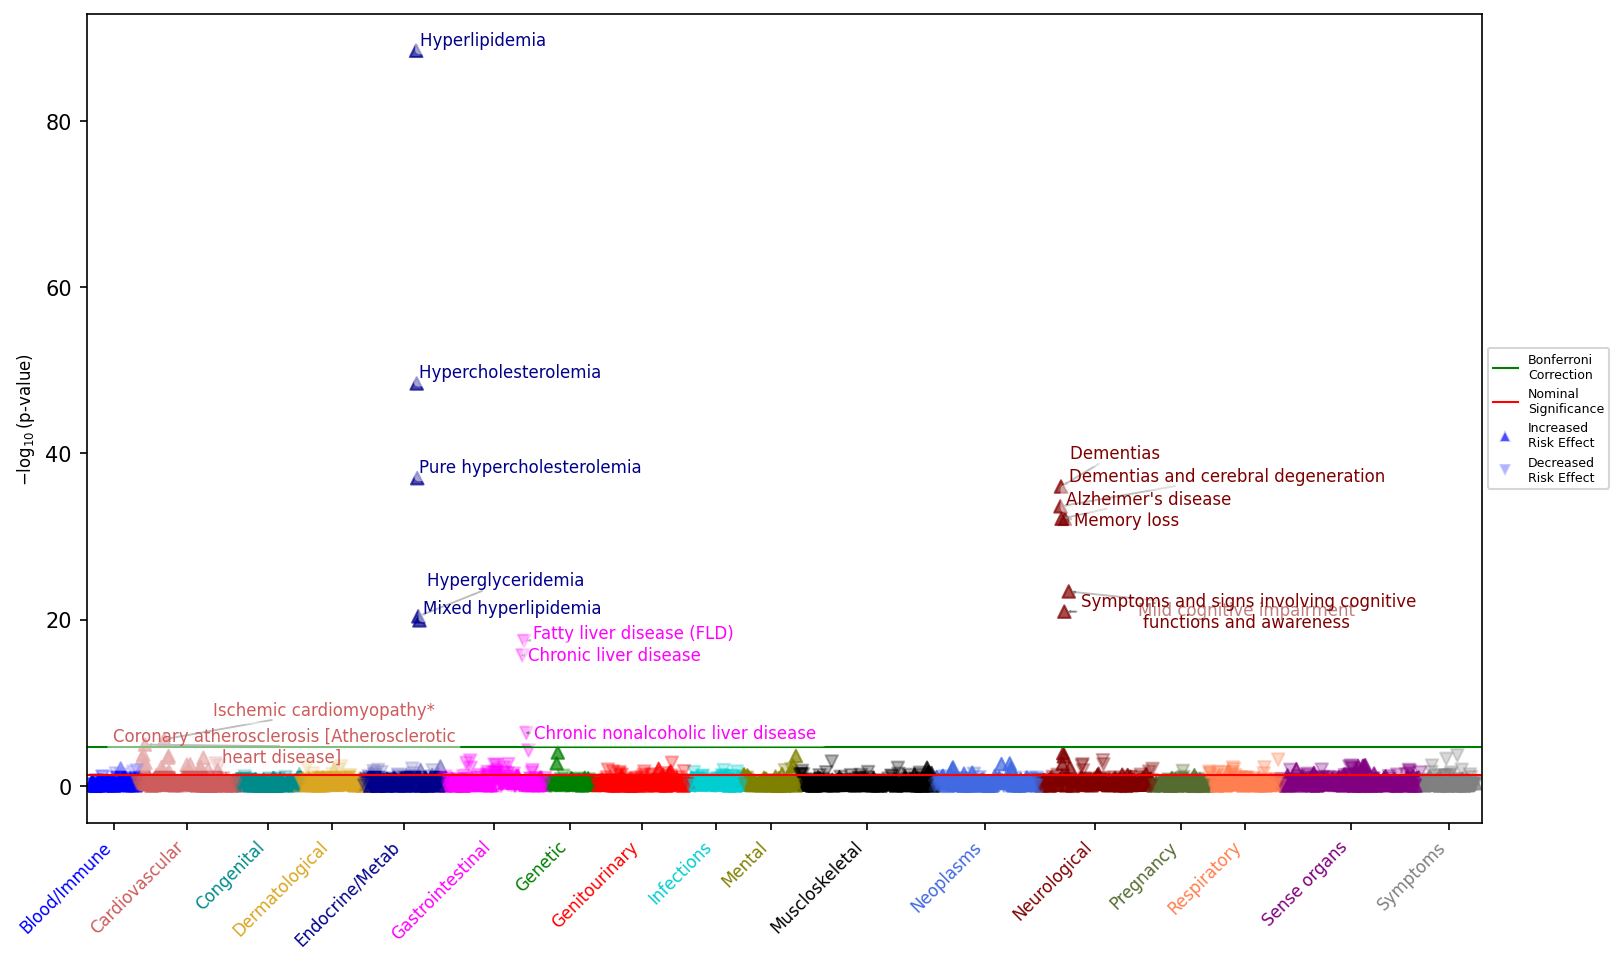

In [7]:
# generate Manhattan plot
p.manhattan(label_values="p_value", label_count=16, save_plot=False)

#### Forest plot

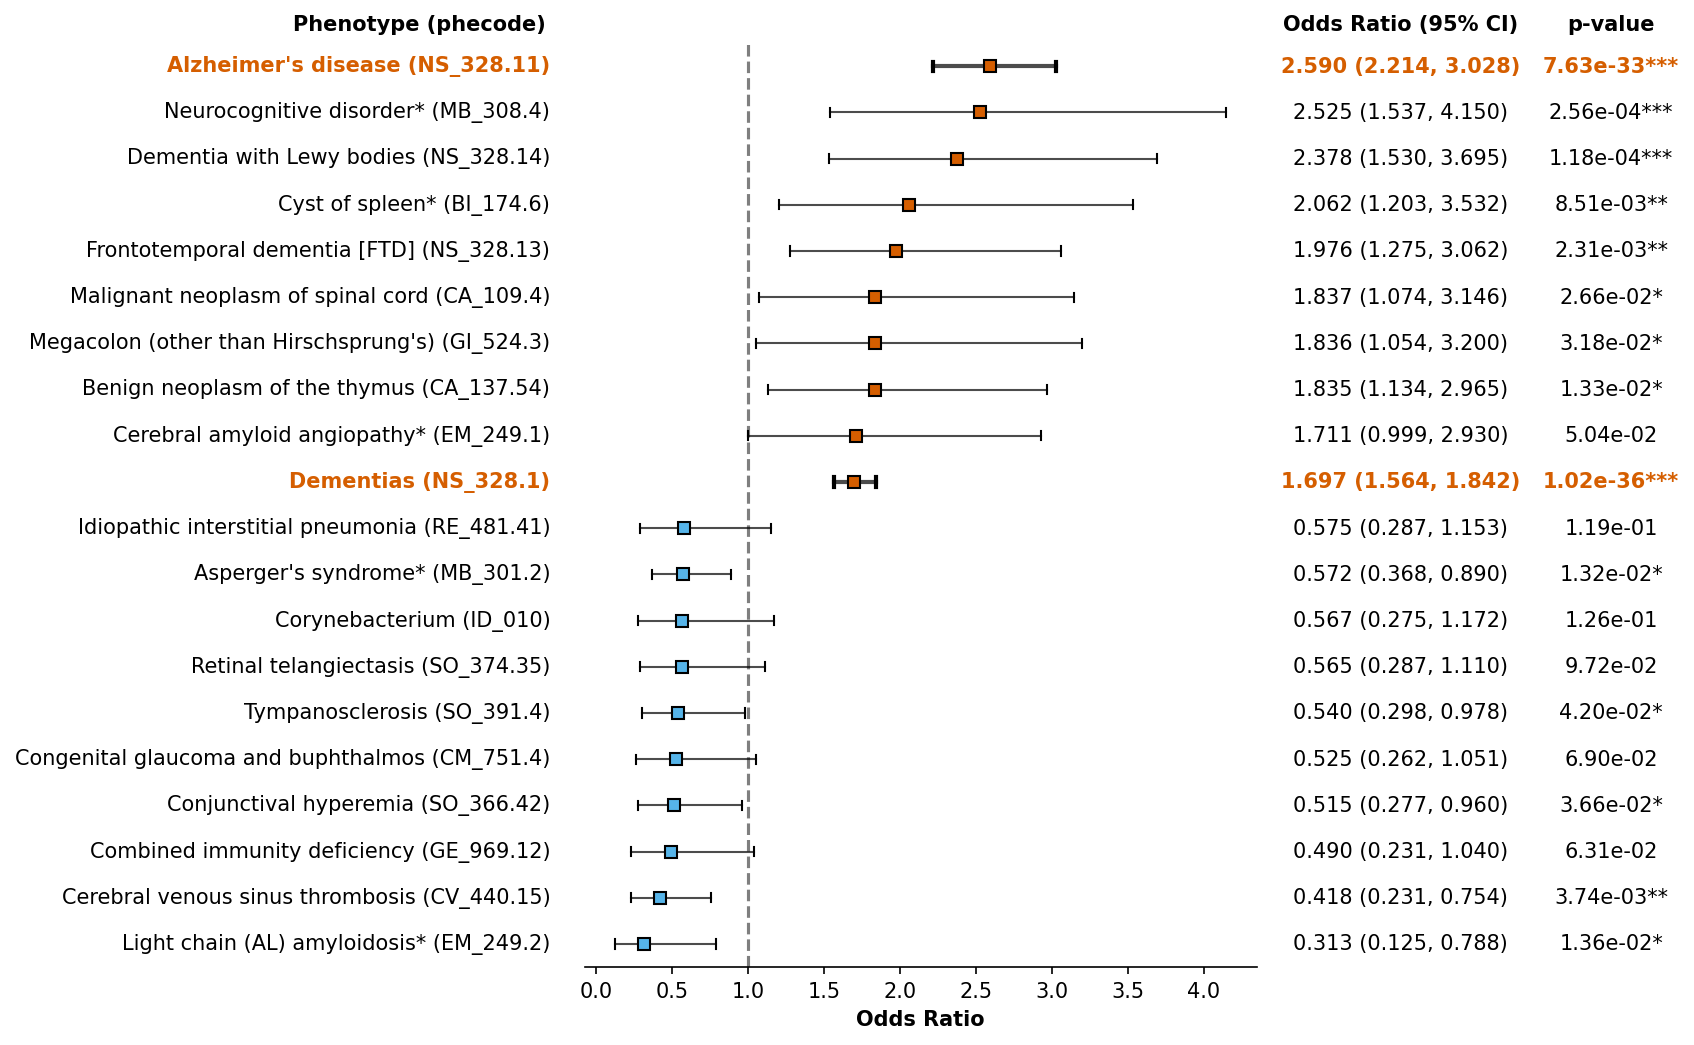

In [8]:
# generate forest plot; by default, it will show top 10 positive and negative phenotypes
p.forest(highlight_significance=True, show_p_value_asterisks=True, save_plot=False)

__This is the end of this demo notebook!__